## Rolling Walk-Forward Out-of-Sample Backtest

This notebook performs the main rolling Markowitz evaluation in the project and is more methodologically demanding than the in-sample static baseline in notebook 07.

Scope of this notebook:
- Re-estimate `mu_t` and `Sigma_t` on each rolling training window.
- Rebuild rolling cluster snapshots from each training window and canonicalize labels at every rebalance.
- Rebalance portfolio weights at the start of each holding block.
- Evaluate rolling out-of-sample performance on unseen future returns.
- Compare `Rolling Defensive`, `Rolling Aggressive Hybrid`, and an equal-weight benchmark on the same out-of-sample dates.
- Track `Rolling Aggressive (Pure)` separately as a coverage-aware diagnostic series with gaps when the pure optimizer is unavailable.

This notebook does not:
- reuse static weights from `06_markowitz_static.ipynb`
- optimize one full-sample static portfolio for backtesting
- reuse a fixed full-sample cluster snapshot across the rolling backtest

Inputs:
- `return_matrix_clean.csv`

Rolling cluster methodology note:
- `derive_window_cluster_snapshot` reconstructs a 4-cluster snapshot from each training window.
- Canonical cluster labels are re-assigned every rebalance before the optimizer and fallback logic run.
- `Rolling Aggressive (Pure)` reports only optimizer-feasible periods, while `Rolling Aggressive Hybrid` books realized returns only when the final aggressive allocation is feasible.


In [1]:
# Imports, plotting setup, and constants
from collections import Counter
from pathlib import Path
import sys

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HELPERS_DIR = Path.cwd() / "helpers"
if str(HELPERS_DIR) not in sys.path:
    sys.path.insert(0, str(HELPERS_DIR))

from rolling_cluster_research import (
    derive_window_cluster_snapshot,
    summarize_aggressive_rebalance_states,
)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

TRADING_DAYS = 252
DISPLAY_THRESHOLD = 0.001
SUM_TOL = 1e-6
WEIGHT_TOL = 1e-5
CLUSTER_TOL = 1e-5
TARGET_TOL = 1e-6
RISK_FREE_RATE = 0.0

print("Imports and plotting configuration loaded.")
print(f"cvxpy version: {cp.__version__}")
print(f"Tolerances -> sum: {SUM_TOL}, weight: {WEIGHT_TOL}, cluster: {CLUSTER_TOL}, target: {TARGET_TOL}")


Imports and plotting configuration loaded.
cvxpy version: 1.7.5
Tolerances -> sum: 1e-06, weight: 1e-05, cluster: 1e-05, target: 1e-06


In [2]:
# Setup paths and load validated inputs
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "backtest_rolling" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("LOAD AND VALIDATE INPUTS")
print("=" * 80)

returns = pd.read_csv(DATA_PROCESSED / "return_matrix_clean.csv", index_col=0, parse_dates=True).sort_index()

assert returns.shape[0] > 0 and returns.shape[1] > 0, "return_matrix_clean.csv must be non-empty"

returns.columns = returns.columns.astype(str).str.upper().str.strip()

assert returns.index.is_unique, "Return matrix index must be unique"
assert not returns.columns.duplicated().any(), "Return matrix contains duplicate tickers"
assert not returns.isna().any().any(), "Return matrix contains missing values"

tickers = sorted(returns.columns.tolist())
returns = returns.loc[:, tickers]

print(f"Return matrix shape: {returns.shape}")
print(f"Return period: {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Ticker universe size: {len(tickers)}")
print("Rolling clusters will be rebuilt from each training window; no fixed snapshot is loaded.")
print(f"Figure export directory: {FIGURES_DIR}")


LOAD AND VALIDATE INPUTS
Return matrix shape: (1435, 29)
Return period: 2020-01-03 to 2025-11-28
Ticker universe size: 29
Rolling clusters will be rebuilt from each training window; no fixed snapshot is loaded.
Figure export directory: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\backtest_rolling\figures


## Rolling Configuration and Rolling Cluster Methodology


In [3]:
print("=" * 80)
print("ROLLING BACKTEST CONFIGURATION")
print("=" * 80)

WINDOW_SIZE = 500
HOLDING_PERIOD = 20
TARGET_ANNUAL_RETURN = 0.14
target_daily_return = TARGET_ANNUAL_RETURN / TRADING_DAYS

rebalance_points = list(range(WINDOW_SIZE, len(returns) - HOLDING_PERIOD, HOLDING_PERIOD))
unused_tail_days = len(returns) - WINDOW_SIZE - len(rebalance_points) * HOLDING_PERIOD

assert WINDOW_SIZE < len(returns), "WINDOW_SIZE must be smaller than the available history"
assert HOLDING_PERIOD > 0, "HOLDING_PERIOD must be positive"
assert len(rebalance_points) > 0, "Rolling configuration produced zero rebalance points"

print(f"WINDOW_SIZE: {WINDOW_SIZE} trading days")
print(f"HOLDING_PERIOD: {HOLDING_PERIOD} trading days")
print(f"TRADING_DAYS: {TRADING_DAYS}")
print(f"TARGET_ANNUAL_RETURN: {TARGET_ANNUAL_RETURN:.2%}")
print(f"target_daily_return: {target_daily_return:.6f}")

print()
print("Configuration meaning:")
print(f"- Training window: {WINDOW_SIZE} daily observations used to estimate rolling mu_t and Sigma_t")
print(f"- Holding block: weights stay fixed for {HOLDING_PERIOD} out-of-sample trading days")
print(f"- Annualization basis: {TRADING_DAYS} trading days per year")

print()
print("Backtest scope:")
print(f"- Total history available: {len(returns)} days")
print(f"- Planned rebalances: {len(rebalance_points)}")
print(f"- First out-of-sample date: {returns.index[rebalance_points[0]].date()}")
print(f"- Last rebalance start: {returns.index[rebalance_points[-1]].date()}")
print(f"- Unused tail days after the final full holding block: {unused_tail_days}")


ROLLING BACKTEST CONFIGURATION
WINDOW_SIZE: 500 trading days
HOLDING_PERIOD: 20 trading days
TRADING_DAYS: 252
TARGET_ANNUAL_RETURN: 14.00%
target_daily_return: 0.000556

Configuration meaning:
- Training window: 500 daily observations used to estimate rolling mu_t and Sigma_t
- Holding block: weights stay fixed for 20 out-of-sample trading days
- Annualization basis: 252 trading days per year

Backtest scope:
- Total history available: 1435 days
- Planned rebalances: 46
- First out-of-sample date: 2022-03-07
- Last rebalance start: 2025-10-13
- Unused tail days after the final full holding block: 15


In [4]:
print("=" * 80)
print("ROLLING CLUSTER METHODOLOGY AND CAPS")
print("=" * 80)

ROLLING_CLUSTER_COUNT = 4
CLUSTER_CAPS_DEFENSIVE = {1: 0.50, 2: 0.40, 3: 0.20, 4: 0.50}
CLUSTER_CAPS_AGGRESSIVE = {1: 0.60, 2: 0.60, 3: 0.30, 4: 0.25}

initial_window_data = returns.iloc[:WINDOW_SIZE]
initial_cluster_snapshot = derive_window_cluster_snapshot(initial_window_data, cluster_count=ROLLING_CLUSTER_COUNT)
cluster_ids_preview = initial_cluster_snapshot.cluster_ids.reindex(initial_window_data.columns).to_numpy(dtype=int)
observed_clusters = sorted(np.unique(cluster_ids_preview).tolist())
assert observed_clusters == [1, 2, 3, 4], "Rolling cluster helper must return the canonical 4-cluster labels"

print(f"ROLLING_CLUSTER_COUNT: {ROLLING_CLUSTER_COUNT}")
print("Initial-window cluster distribution preview:")
for cid in observed_clusters:
    stock_list = initial_cluster_snapshot.cluster_ids.index[initial_cluster_snapshot.cluster_ids == cid].tolist()
    preview = ", ".join(stock_list[:5])
    suffix = "..." if len(stock_list) > 5 else ""
    print(f"- Cluster {cid}: {len(stock_list)} tickers -> {preview}{suffix}")

print()
print("Defensive cluster caps:")
for cid, cap in sorted(CLUSTER_CAPS_DEFENSIVE.items()):
    print(f"- Cluster {cid}: <= {cap:.0%}")

print()
print("Aggressive cluster caps:")
for cid, cap in sorted(CLUSTER_CAPS_AGGRESSIVE.items()):
    print(f"- Cluster {cid}: <= {cap:.0%}")

print()
print("Rolling cluster methodology note:")
print("- Cluster structure is rebuilt from each trailing training window, not loaded from a fixed full-sample CSV.")
print("- Canonical labels 1-4 are reassigned through derive_window_cluster_snapshot before each rebalance.")
print("- Aggressive fallback uses the current window's canonical labels, preserving the approved cap dictionaries.")


ROLLING CLUSTER METHODOLOGY AND CAPS
ROLLING_CLUSTER_COUNT: 4
Initial-window cluster distribution preview:
- Cluster 1: 7 tickers -> FPT, GVR, HPG, MSN, SHB...
- Cluster 2: 11 tickers -> ACB, BID, CTG, HDB, LPB...
- Cluster 3: 3 tickers -> VHM, VIC, VRE
- Cluster 4: 8 tickers -> BCM, DGC, GAS, MWG, PLX...

Defensive cluster caps:
- Cluster 1: <= 50%
- Cluster 2: <= 40%
- Cluster 3: <= 20%
- Cluster 4: <= 50%

Aggressive cluster caps:
- Cluster 1: <= 60%
- Cluster 2: <= 60%
- Cluster 3: <= 30%
- Cluster 4: <= 25%

Rolling cluster methodology note:
- Cluster structure is rebuilt from each trailing training window, not loaded from a fixed full-sample CSV.
- Canonical labels 1-4 are reassigned through derive_window_cluster_snapshot before each rebalance.
- Aggressive fallback uses the current window's canonical labels, preserving the approved cap dictionaries.


## Rolling Optimizers and Feasibility Checks


In [5]:
def build_defensive_fallback(cluster_ids, caps):
    """Cap-feasible fallback that allocates across present clusters in proportion to available cap."""
    weights = np.zeros(len(cluster_ids), dtype=float)
    present_clusters = [cid for cid in sorted(np.unique(cluster_ids)) if cid in caps]
    cap_total = sum(caps[cid] for cid in present_clusters)
    for cid in present_clusters:
        idx = np.where(cluster_ids == cid)[0]
        cluster_weight = caps[cid] / cap_total
        weights[idx] = cluster_weight / len(idx)
    return weights


def build_aggressive_fallback(cluster_ids, caps):
    """Cap-aware fallback that prioritizes canonical clusters 1 and 2 and returns NaNs if full feasibility cannot be restored."""
    weights = np.zeros(len(cluster_ids), dtype=float)
    present_clusters = [cid for cid in sorted(np.unique(cluster_ids)) if cid in caps]
    preferred_clusters = [cid for cid in (1, 2) if cid in present_clusters]
    allocation_order = preferred_clusters + [cid for cid in present_clusters if cid not in preferred_clusters]

    remaining_weight = 1.0
    for cid in allocation_order:
        if remaining_weight <= 1e-12:
            break
        idx = np.where(cluster_ids == cid)[0]
        if len(idx) == 0:
            continue
        cluster_weight = min(caps[cid], remaining_weight)
        weights[idx] = cluster_weight / len(idx)
        remaining_weight -= cluster_weight

    if remaining_weight > 1e-8:
        return np.full(len(cluster_ids), np.nan, dtype=float)
    return weights


def solve_markowitz_defensive(mu, Sigma, cluster_ids, caps, verbose=False):
    """
    Rolling Defensive strategy: global minimum variance.

    Objective:
        minimize w^T Sigma w

    Constraints:
        sum(w) = 1
        w >= 0
        sum(weights within each cluster) <= cluster cap

    Fallback behavior:
        if the solver errors or returns no usable weight vector, use equal-weight over the full universe.
    """
    n_assets = len(cluster_ids)

    try:
        w = cp.Variable(n_assets)
        objective = cp.Minimize(cp.quad_form(w, Sigma))
        constraints = [cp.sum(w) == 1, w >= 0]

        for cid, cap in caps.items():
            idx = np.where(cluster_ids == cid)[0]
            if len(idx) > 0:
                constraints.append(cp.sum(w[idx]) <= cap)

        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCS, verbose=verbose)

        weights = None if w.value is None else np.asarray(w.value, dtype=float).reshape(-1)
        if weights is None:
            return {
                "weights": build_defensive_fallback(cluster_ids, caps),
                "solver_status": problem.status or "no_solution",
                "used_fallback": True,
                "fallback_reason": "solver_returned_no_weights",
            }

        return {
            "weights": weights,
            "solver_status": problem.status,
            "used_fallback": False,
            "fallback_reason": None,
        }
    except Exception as exc:
        return {
            "weights": build_defensive_fallback(cluster_ids, caps),
            "solver_status": f"error:{type(exc).__name__}",
            "used_fallback": True,
            "fallback_reason": str(exc),
        }


def solve_markowitz_aggressive(mu, Sigma, cluster_ids, caps, target_return, verbose=False):
    """
    Rolling Aggressive strategy: target-return minimum variance.

    Objective:
        minimize w^T Sigma w

    Constraints:
        sum(w) = 1
        w >= 0
        w^T mu >= target_return
        sum(weights within each cluster) <= cluster cap

    Notes:
        - target_return is a daily target, approximated from a 14% annual target as 0.14 / 252.
        - this is not a maximum-Sharpe, tangency, or unconstrained maximum-return portfolio.

    Fallback behavior:
        if the pure optimizer is unavailable, hybrid fallback first tries a cap-aware allocation from the current rolling window.
        The pure aggressive series records NaN for those periods, and the hybrid series also records NaN if the final fallback allocation remains infeasible.
    """
    n_assets = len(cluster_ids)

    try:
        w = cp.Variable(n_assets)
        objective = cp.Minimize(cp.quad_form(w, Sigma))
        constraints = [cp.sum(w) == 1, w >= 0, w @ mu >= target_return]

        for cid, cap in caps.items():
            idx = np.where(cluster_ids == cid)[0]
            if len(idx) > 0:
                constraints.append(cp.sum(w[idx]) <= cap)

        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCS, verbose=verbose)

        weights = None if w.value is None else np.asarray(w.value, dtype=float).reshape(-1)
        if weights is None:
            return {
                "weights": build_aggressive_fallback(cluster_ids, caps),
                "solver_status": problem.status or "no_solution",
                "used_fallback": True,
                "fallback_reason": "solver_returned_no_weights",
            }

        return {
            "weights": weights,
            "solver_status": problem.status,
            "used_fallback": False,
            "fallback_reason": None,
        }
    except Exception as exc:
        return {
            "weights": build_aggressive_fallback(cluster_ids, caps),
            "solver_status": f"error:{type(exc).__name__}",
            "used_fallback": True,
            "fallback_reason": str(exc),
        }


def evaluate_feasibility(weights, cluster_ids, caps, mu=None, target_return=None):
    """Post-solve numerical feasibility check for each rebalance."""
    weights = np.asarray(weights, dtype=float).reshape(-1)
    n_nan_weights = int(np.isnan(weights).sum())

    if n_nan_weights == len(weights):
        weight_sum_error = np.inf
        min_weight = np.nan
    else:
        weight_sum_error = abs(np.nansum(weights) - 1.0)
        min_weight = float(np.nanmin(weights))

    cluster_allocations = {}
    max_cluster_violation = 0.0
    for cid, cap in caps.items():
        idx = np.where(cluster_ids == cid)[0]
        allocation = float(np.nansum(weights[idx])) if len(idx) > 0 else 0.0
        cluster_allocations[cid] = allocation
        max_cluster_violation = max(max_cluster_violation, allocation - cap)

    target_return_slack = np.nan
    if mu is not None and target_return is not None:
        target_return_slack = float(np.nansum(weights * mu) - target_return)

    feasible = (
        n_nan_weights == 0
        and weight_sum_error <= SUM_TOL
        and min_weight >= -WEIGHT_TOL
        and max_cluster_violation <= CLUSTER_TOL
        and (np.isnan(target_return_slack) or target_return_slack >= -TARGET_TOL)
    )

    return {
        "weight_sum_error": float(weight_sum_error),
        "min_weight": min_weight,
        "max_cluster_violation": float(max_cluster_violation),
        "target_return_slack": float(target_return_slack) if not np.isnan(target_return_slack) else np.nan,
        "n_nan_weights": n_nan_weights,
        "cluster_allocations": cluster_allocations,
        "feasible": bool(feasible),
    }


print("Rolling optimizers and feasibility helper are ready.")
print("- solve_markowitz_defensive(): rolling GMV with cluster caps")
print("- solve_markowitz_aggressive(): rolling target-return minimum variance")
print("- evaluate_feasibility(): post-solve numerical feasibility diagnostics")


Rolling optimizers and feasibility helper are ready.
- solve_markowitz_defensive(): rolling GMV with cluster caps
- solve_markowitz_aggressive(): rolling target-return minimum variance
- evaluate_feasibility(): post-solve numerical feasibility diagnostics


## Rolling Walk-Forward Loop and Rebalance Diagnostics


In [6]:
print("=" * 80)
print("ROLLING WALK-FORWARD BACKTEST")
print("=" * 80)

print("Rolling methodology:")
print(f"- Train on the trailing {WINDOW_SIZE} days")
print(f"- Hold weights fixed for the next {HOLDING_PERIOD} out-of-sample trading days")
print("- Re-estimate mu_t and Sigma_t at each rebalance")
print("- Rebuild and canonicalize rolling clusters at each rebalance")
print("- Use simple returns for realized portfolio performance inside each holding block")
print()

rolling_ret_def = []
rolling_ret_agg_pure = []
rolling_ret_agg_hybrid = []
rolling_dates = []
rebalance_info = []

solver_status_counts_def = Counter()
solver_status_counts_agg = Counter()
solver_success_def = 0
solver_success_agg = 0
solver_fail_def = 0
solver_fail_agg = 0
fallback_def = 0
fallback_agg = 0
infeasible_def = 0
infeasible_agg = 0
clean_feasible_def = 0
clean_feasible_agg = 0

for rebalance_number, t in enumerate(rebalance_points, start=1):
    rebalance_date = returns.index[t]
    if rebalance_number == 1 or rebalance_number % 10 == 0:
        print(f"Rebalance {rebalance_number:02d}/{len(rebalance_points)} | date {rebalance_date.date()} | train[{t - WINDOW_SIZE}:{t}] -> test[{t}:{t + HOLDING_PERIOD}]")

    window_data = returns.iloc[t - WINDOW_SIZE : t]
    future_log_returns = returns.iloc[t : t + HOLDING_PERIOD]
    future_simple = np.exp(future_log_returns) - 1

    cluster_snapshot = derive_window_cluster_snapshot(window_data, cluster_count=ROLLING_CLUSTER_COUNT)
    cluster_ids_t = cluster_snapshot.cluster_ids.reindex(window_data.columns).to_numpy(dtype=int)

    mu_t = window_data.mean().to_numpy()
    Sigma_t = window_data.cov().to_numpy()

    result_def = solve_markowitz_defensive(mu_t, Sigma_t, cluster_ids_t, CLUSTER_CAPS_DEFENSIVE)
    solver_status_counts_def[result_def["solver_status"]] += 1

    if result_def["used_fallback"]:
        solver_fail_def += 1
        fallback_def += 1
        final_w_def = result_def["weights"]
        feasibility_def = evaluate_feasibility(final_w_def, cluster_ids_t, CLUSTER_CAPS_DEFENSIVE)
        assert feasibility_def["feasible"], "Defensive fallback weights must remain feasible"
        final_source_def = "solver_fallback"
        solver_feasible_def = False
        final_feasible_def = feasibility_def["feasible"]
    else:
        solver_success_def += 1
        solver_feasibility_def = evaluate_feasibility(result_def["weights"], cluster_ids_t, CLUSTER_CAPS_DEFENSIVE)
        solver_feasible_def = solver_feasibility_def["feasible"]
        if solver_feasible_def:
            clean_feasible_def += 1
            final_w_def = result_def["weights"]
            feasibility_def = solver_feasibility_def
            final_source_def = "solver_solution"
            final_feasible_def = True
        else:
            infeasible_def += 1
            fallback_def += 1
            final_w_def = build_defensive_fallback(cluster_ids_t, CLUSTER_CAPS_DEFENSIVE)
            feasibility_def = evaluate_feasibility(final_w_def, cluster_ids_t, CLUSTER_CAPS_DEFENSIVE)
            assert feasibility_def["feasible"], "Defensive fallback weights must remain feasible"
            final_source_def = "post_check_fallback"
            final_feasible_def = feasibility_def["feasible"]

    result_agg = solve_markowitz_aggressive(mu_t, Sigma_t, cluster_ids_t, CLUSTER_CAPS_AGGRESSIVE, target_daily_return)
    solver_status_counts_agg[result_agg["solver_status"]] += 1

    aggressive_used_fallback = False
    target_return_slack_agg_pure = np.nan

    if result_agg["used_fallback"]:
        solver_fail_agg += 1
        fallback_agg += 1
        aggressive_used_fallback = True
        final_w_agg_hybrid = result_agg["weights"]
        feasibility_agg = evaluate_feasibility(final_w_agg_hybrid, cluster_ids_t, CLUSTER_CAPS_AGGRESSIVE, mu=mu_t, target_return=target_daily_return)
        final_w_agg_pure = np.full(len(cluster_ids_t), np.nan, dtype=float)
        aggressive_state = "fallback_used"
        final_source_agg = "solver_fallback"
        solver_feasible_agg = False
        final_feasible_agg = feasibility_agg["feasible"]
    else:
        solver_success_agg += 1
        solver_feasibility_agg = evaluate_feasibility(result_agg["weights"], cluster_ids_t, CLUSTER_CAPS_AGGRESSIVE, mu=mu_t, target_return=target_daily_return)
        solver_feasible_agg = solver_feasibility_agg["feasible"]
        if solver_feasible_agg:
            clean_feasible_agg += 1
            final_w_agg_hybrid = result_agg["weights"]
            final_w_agg_pure = result_agg["weights"]
            feasibility_agg = solver_feasibility_agg
            target_return_slack_agg_pure = solver_feasibility_agg["target_return_slack"]
            aggressive_state = "pure_feasible"
            final_source_agg = "solver_solution"
            final_feasible_agg = True
        else:
            infeasible_agg += 1
            fallback_agg += 1
            aggressive_used_fallback = True
            final_w_agg_hybrid = build_aggressive_fallback(cluster_ids_t, CLUSTER_CAPS_AGGRESSIVE)
            feasibility_agg = evaluate_feasibility(final_w_agg_hybrid, cluster_ids_t, CLUSTER_CAPS_AGGRESSIVE, mu=mu_t, target_return=target_daily_return)
            final_w_agg_pure = np.full(len(cluster_ids_t), np.nan, dtype=float)
            aggressive_state = "fallback_used"
            final_source_agg = "post_check_fallback"
            final_feasible_agg = feasibility_agg["feasible"]

    ret_def_period = future_simple.to_numpy() @ final_w_def
    if final_feasible_agg:
        ret_agg_hybrid_period = future_simple.to_numpy() @ final_w_agg_hybrid
    else:
        ret_agg_hybrid_period = np.full(len(future_simple), np.nan, dtype=float)
    if aggressive_state == "pure_feasible":
        ret_agg_pure_period = future_simple.to_numpy() @ final_w_agg_pure
    else:
        ret_agg_pure_period = np.full(len(future_simple), np.nan, dtype=float)

    rolling_ret_def.extend(ret_def_period)
    rolling_ret_agg_pure.extend(ret_agg_pure_period)
    rolling_ret_agg_hybrid.extend(ret_agg_hybrid_period)
    rolling_dates.extend(future_log_returns.index)

    rebalance_info.append(
        {
            "date": rebalance_date,
            "window_start": window_data.index[0],
            "window_end": window_data.index[-1],
            "holding_end": future_log_returns.index[-1],
            "solver_status_def": result_def["solver_status"],
            "solver_status_agg": result_agg["solver_status"],
            "solver_solution_feasible_def": solver_feasible_def,
            "solver_solution_feasible_agg": solver_feasible_agg,
            "used_fallback_def": final_source_def != "solver_solution",
            "used_fallback_agg": aggressive_used_fallback,
            "aggressive_state": aggressive_state,
            "aggressive_used_fallback": aggressive_used_fallback,
            "final_feasible_def": final_feasible_def,
            "final_feasible_agg": final_feasible_agg,
            "final_source_def": final_source_def,
            "final_source_agg": final_source_agg,
            "n_stocks_def": int((final_w_def > DISPLAY_THRESHOLD).sum()),
            "n_stocks_agg": int((np.nan_to_num(final_w_agg_hybrid, nan=0.0) > DISPLAY_THRESHOLD).sum()),
            "top_weight_def": float(final_w_def.max()),
            "top_weight_agg": float(np.nanmax(final_w_agg_hybrid)),
            "weight_sum_error_def": feasibility_def["weight_sum_error"],
            "weight_sum_error_agg": feasibility_agg["weight_sum_error"],
            "min_weight_def": feasibility_def["min_weight"],
            "min_weight_agg": feasibility_agg["min_weight"],
            "max_cluster_violation_def": feasibility_def["max_cluster_violation"],
            "max_cluster_violation_agg": feasibility_agg["max_cluster_violation"],
            "target_return_slack_agg": feasibility_agg["target_return_slack"],
            "target_return_slack_agg_pure": target_return_slack_agg_pure,
            "n_nan_weights_def": feasibility_def["n_nan_weights"],
            "n_nan_weights_agg": feasibility_agg["n_nan_weights"],
        }
    )

final_feasible_def_count = sum(item["final_feasible_def"] for item in rebalance_info)
final_feasible_agg_count = sum(item["final_feasible_agg"] for item in rebalance_info)
aggressive_diagnostics = summarize_aggressive_rebalance_states(rebalance_info)

print()
print("Rolling loop completed.")
print(f"- Total rebalances: {len(rebalance_points)}")
print(f"- Defensive solver successes before post-check: {solver_success_def}")
print(f"- Aggressive solver successes before post-check: {solver_success_agg}")
print(f"- Defensive solver failures: {solver_fail_def}")
print(f"- Aggressive solver failures: {solver_fail_agg}")
print(f"- Defensive infeasible-after-check: {infeasible_def}")
print(f"- Aggressive infeasible-after-check: {infeasible_agg}")
print(f"- Defensive fallback uses: {fallback_def}")
print(f"- Aggressive fallback rebalances (Hybrid path): {aggressive_diagnostics['fallback_rebalances']}/{aggressive_diagnostics['total_rebalances']}")
print(f"- Clean feasible defensive solver solutions: {clean_feasible_def}")
print(f"- Pure-feasible aggressive solver solutions: {aggressive_diagnostics['pure_feasible_rebalances']}/{aggressive_diagnostics['total_rebalances']} ({aggressive_diagnostics['pure_feasible_ratio']:.2%})")
print(f"- Final feasible defensive selections after fallback: {final_feasible_def_count}")
print(f"- Aggressive Hybrid final feasible selections after fallback: {final_feasible_agg_count}")
print(f"- Out-of-sample daily observations collected: {len(rolling_ret_def)}")
print(f"- OOS date range: {rolling_dates[0].date()} to {rolling_dates[-1].date()}")


ROLLING WALK-FORWARD BACKTEST
Rolling methodology:
- Train on the trailing 500 days
- Hold weights fixed for the next 20 out-of-sample trading days
- Re-estimate mu_t and Sigma_t at each rebalance
- Rebuild and canonicalize rolling clusters at each rebalance
- Use simple returns for realized portfolio performance inside each holding block

Rebalance 01/46 | date 2022-03-07 | train[0:500] -> test[500:520]


Rebalance 10/46 | date 2022-11-21 | train[180:680] -> test[680:700]


Rebalance 20/46 | date 2023-09-12 | train[380:880] -> test[880:900]


Rebalance 30/46 | date 2024-07-02 | train[580:1080] -> test[1080:1100]


Rebalance 40/46 | date 2025-04-21 | train[780:1280] -> test[1280:1300]

Rolling loop completed.
- Total rebalances: 46
- Defensive solver successes before post-check: 46
- Aggressive solver successes before post-check: 46
- Defensive solver failures: 0
- Aggressive solver failures: 0
- Defensive infeasible-after-check: 6
- Aggressive infeasible-after-check: 4
- Defensive fallback uses: 6
- Aggressive fallback rebalances (Hybrid path): 4/46
- Clean feasible defensive solver solutions: 40
- Pure-feasible aggressive solver solutions: 42/46 (91.30%)
- Final feasible defensive selections after fallback: 46
- Aggressive Hybrid final feasible selections after fallback: 45
- Out-of-sample daily observations collected: 920
- OOS date range: 2022-03-07 to 2025-11-07


## Rolling Return Series and Rebalance Summary


In [7]:
print("=" * 80)
print("CREATE ROLLING RETURN SERIES")
print("=" * 80)

ret_def = pd.Series(rolling_ret_def, index=rolling_dates, name="Rolling_Defensive")
ret_agg_pure = pd.Series(rolling_ret_agg_pure, index=rolling_dates, name="Rolling_Aggressive_Pure")
ret_agg_hybrid = pd.Series(rolling_ret_agg_hybrid, index=rolling_dates, name="Rolling_Aggressive_Hybrid")

if ret_def.index.duplicated().any() or ret_agg_pure.index.duplicated().any() or ret_agg_hybrid.index.duplicated().any():
    duplicate_count = int(ret_def.index.duplicated().sum())
    print(f"Duplicate out-of-sample dates found: {duplicate_count}. Keeping the first occurrence.")
    keep_mask = ~ret_def.index.duplicated(keep="first")
    ret_def = ret_def[keep_mask]
    ret_agg_pure = ret_agg_pure[keep_mask]
    ret_agg_hybrid = ret_agg_hybrid[keep_mask]

assert ret_def.index.equals(ret_agg_pure.index), "Rolling Defensive and pure aggressive date indices must match"
assert ret_def.index.equals(ret_agg_hybrid.index), "Rolling Defensive and hybrid aggressive date indices must match"

rebalance_summary = pd.DataFrame(rebalance_info)
pure_active_oos_days = int(ret_agg_pure.notna().sum())
pure_coverage_ratio = pure_active_oos_days / len(ret_agg_pure) if len(ret_agg_pure) else np.nan
hybrid_active_oos_days = int(ret_agg_hybrid.notna().sum())
hybrid_coverage_ratio = hybrid_active_oos_days / len(ret_agg_hybrid) if len(ret_agg_hybrid) else np.nan

print(f"Rolling Defensive length: {len(ret_def)}")
print(f"Rolling Aggressive (Pure) length with NaN placeholders: {len(ret_agg_pure)}")
print(f"Rolling Aggressive Hybrid length with feasibility gating: {len(ret_agg_hybrid)}")
print(f"Rolling Aggressive (Pure) active OOS days: {pure_active_oos_days}/{len(ret_agg_pure)} ({pure_coverage_ratio:.2%})")
print(f"Rolling Aggressive Hybrid active OOS days: {hybrid_active_oos_days}/{len(ret_agg_hybrid)} ({hybrid_coverage_ratio:.2%})")
print(f"Daily OOS date range: {ret_def.index[0].date()} to {ret_def.index[-1].date()}")
print(f"Average effective holdings (defensive): {rebalance_summary['n_stocks_def'].mean():.2f}")
print(f"Average effective holdings (aggressive hybrid): {rebalance_summary['n_stocks_agg'].mean():.2f}")
print(f"Fallback counts -> defensive: {int(rebalance_summary['used_fallback_def'].sum())}, aggressive hybrid: {aggressive_diagnostics['fallback_rebalances']}")
print(f"Aggressive pure-feasible rebalances: {aggressive_diagnostics['pure_feasible_rebalances']}/{aggressive_diagnostics['total_rebalances']} ({aggressive_diagnostics['pure_feasible_ratio']:.2%})")
print(f"Hybrid final feasible selections: {int(rebalance_summary['final_feasible_agg'].sum())}/{len(rebalance_points)}")

print()
print("Rebalance diagnostics preview:")
preview_columns = ["date", "solver_status_def", "solver_status_agg", "aggressive_state", "aggressive_used_fallback", "final_feasible_def", "final_feasible_agg", "n_stocks_def", "n_stocks_agg", "max_cluster_violation_def", "max_cluster_violation_agg", "target_return_slack_agg"]
print(rebalance_summary.loc[:, preview_columns].head(5).to_string(index=False))


CREATE ROLLING RETURN SERIES
Rolling Defensive length: 920
Rolling Aggressive (Pure) length with NaN placeholders: 920
Rolling Aggressive Hybrid length with feasibility gating: 920
Rolling Aggressive (Pure) active OOS days: 840/920 (91.30%)
Rolling Aggressive Hybrid active OOS days: 900/920 (97.83%)
Daily OOS date range: 2022-03-07 to 2025-11-07
Average effective holdings (defensive): 13.83
Average effective holdings (aggressive hybrid): 11.98
Fallback counts -> defensive: 6, aggressive hybrid: 4
Aggressive pure-feasible rebalances: 42/46 (91.30%)
Hybrid final feasible selections: 45/46

Rebalance diagnostics preview:
      date solver_status_def solver_status_agg aggressive_state  aggressive_used_fallback  final_feasible_def  final_feasible_agg  n_stocks_def  n_stocks_agg  max_cluster_violation_def  max_cluster_violation_agg  target_return_slack_agg
2022-03-07           optimal           optimal    pure_feasible                     False                True                True        

## Rolling Performance Metrics on Simple-Return Paths


In [8]:
def calculate_drawdown(nav):
    """High-water-mark drawdown series."""
    running_max = nav.cummax()
    return nav / running_max - 1.0


def calculate_metrics(returns_series):
    """Performance metrics from daily portfolio simple returns."""
    mean_daily = returns_series.mean()
    annualized_mean_return = mean_daily * TRADING_DAYS

    daily_vol = returns_series.std()
    annualized_volatility = daily_vol * np.sqrt(TRADING_DAYS)

    excess_annual_return = annualized_mean_return - RISK_FREE_RATE
    sharpe = excess_annual_return / annualized_volatility if annualized_volatility > 0 else np.nan

    nav = (1.0 + returns_series).cumprod()
    drawdown = calculate_drawdown(nav)
    max_drawdown = drawdown.min()

    return {
        "Annualized Mean Return (%)": annualized_mean_return * 100,
        "Annualized Volatility (%)": annualized_volatility * 100,
        "Sharpe Ratio (Rf=0)": sharpe,
        "Max Drawdown (%)": max_drawdown * 100,
        "Final NAV": float(nav.iloc[-1]),
        "NAV": nav,
        "Drawdown": drawdown,
    }


print("=" * 80)
print("CALCULATE ROLLING PERFORMANCE METRICS")
print("=" * 80)
print("Metric convention: annualized mean return, annualized volatility, Sharpe with Rf = 0, and drawdown from simple-return NAV.")

metrics_def = calculate_metrics(ret_def)
pure_returns = ret_agg_pure.dropna()
hybrid_returns = ret_agg_hybrid.dropna()
assert len(pure_returns) > 0, "Rolling Aggressive (Pure) has zero active OOS days; review rolling diagnostics"
assert len(hybrid_returns) > 0, "Rolling Aggressive Hybrid has zero active OOS days; review rolling diagnostics"
metrics_agg_pure = calculate_metrics(pure_returns)
metrics_agg_hybrid = calculate_metrics(hybrid_returns)

print(f"Rolling Aggressive (Pure) metrics are computed on {pure_active_oos_days} active OOS days ({pure_coverage_ratio:.2%} coverage).")
print(f"Rolling Aggressive Hybrid metrics are computed on {hybrid_active_oos_days} active OOS days ({hybrid_coverage_ratio:.2%} coverage).")

for label, metrics in [("Rolling Defensive", metrics_def), ("Rolling Aggressive Hybrid", metrics_agg_hybrid)]:
    print()
    print(f"{label}:")
    print(f"- Annualized mean return: {metrics['Annualized Mean Return (%)']:.2f}%")
    print(f"- Annualized volatility: {metrics['Annualized Volatility (%)']:.2f}%")
    print(f"- Sharpe ratio (Rf=0): {metrics['Sharpe Ratio (Rf=0)']:.4f}")
    print(f"- Max drawdown: {metrics['Max Drawdown (%)']:.2f}%")
    print(f"- Final NAV: {metrics['Final NAV']:.4f}")

print()
print("Coverage-aware pure aggressive diagnostic:")
print(f"- Annualized mean return over active days: {metrics_agg_pure['Annualized Mean Return (%)']:.2f}%")
print(f"- Annualized volatility over active days: {metrics_agg_pure['Annualized Volatility (%)']:.2f}%")
print(f"- Sharpe ratio (Rf=0) over active days: {metrics_agg_pure['Sharpe Ratio (Rf=0)']:.4f}")
print(f"- Max drawdown over active days: {metrics_agg_pure['Max Drawdown (%)']:.2f}%")
print(f"- Final NAV across active days only: {metrics_agg_pure['Final NAV']:.4f}")


CALCULATE ROLLING PERFORMANCE METRICS
Metric convention: annualized mean return, annualized volatility, Sharpe with Rf = 0, and drawdown from simple-return NAV.
Rolling Aggressive (Pure) metrics are computed on 840 active OOS days (91.30% coverage).
Rolling Aggressive Hybrid metrics are computed on 900 active OOS days (97.83% coverage).

Rolling Defensive:
- Annualized mean return: 7.58%
- Annualized volatility: 17.53%
- Sharpe ratio (Rf=0): 0.4322
- Max drawdown: -23.33%
- Final NAV: 1.2465

Rolling Aggressive Hybrid:
- Annualized mean return: 12.48%
- Annualized volatility: 18.79%
- Sharpe ratio (Rf=0): 0.6643
- Max drawdown: -25.36%
- Final NAV: 1.4661

Coverage-aware pure aggressive diagnostic:
- Annualized mean return over active days: 11.01%
- Annualized volatility over active days: 18.48%
- Sharpe ratio (Rf=0) over active days: 0.5957
- Max drawdown over active days: -21.98%
- Final NAV across active days only: 1.3633


## Equal-Weight Benchmark on the Same Out-of-Sample Dates


In [9]:
print("=" * 80)
print("EQUAL-WEIGHT BENCHMARK")
print("=" * 80)

w_eq = np.ones(returns.shape[1], dtype=float) / returns.shape[1]
benchmark_simple = np.exp(returns.loc[ret_def.index]) - 1
benchmark_returns = benchmark_simple.to_numpy() @ w_eq
ret_bench = pd.Series(benchmark_returns, index=ret_def.index, name="Equal_Weight_Benchmark")

metrics_bench = calculate_metrics(ret_bench)

print("Benchmark definition:")
print("- Equal-weight across the same 29-ticker universe")
print("- Same daily frequency and same out-of-sample date range as the rolling strategies")
print("- Same simple-return backtest convention")

print()
print("Equal-Weight Benchmark:")
print(f"- Annualized mean return: {metrics_bench['Annualized Mean Return (%)']:.2f}%")
print(f"- Annualized volatility: {metrics_bench['Annualized Volatility (%)']:.2f}%")
print(f"- Sharpe ratio (Rf=0): {metrics_bench['Sharpe Ratio (Rf=0)']:.4f}")
print(f"- Max drawdown: {metrics_bench['Max Drawdown (%)']:.2f}%")
print(f"- Final NAV: {metrics_bench['Final NAV']:.4f}")


EQUAL-WEIGHT BENCHMARK
Benchmark definition:
- Equal-weight across the same 29-ticker universe
- Same daily frequency and same out-of-sample date range as the rolling strategies
- Same simple-return backtest convention

Equal-Weight Benchmark:
- Annualized mean return: 10.65%
- Annualized volatility: 21.66%
- Sharpe ratio (Rf=0): 0.4918
- Max drawdown: -39.02%
- Final NAV: 1.3536


## Visualization and Performance Comparison


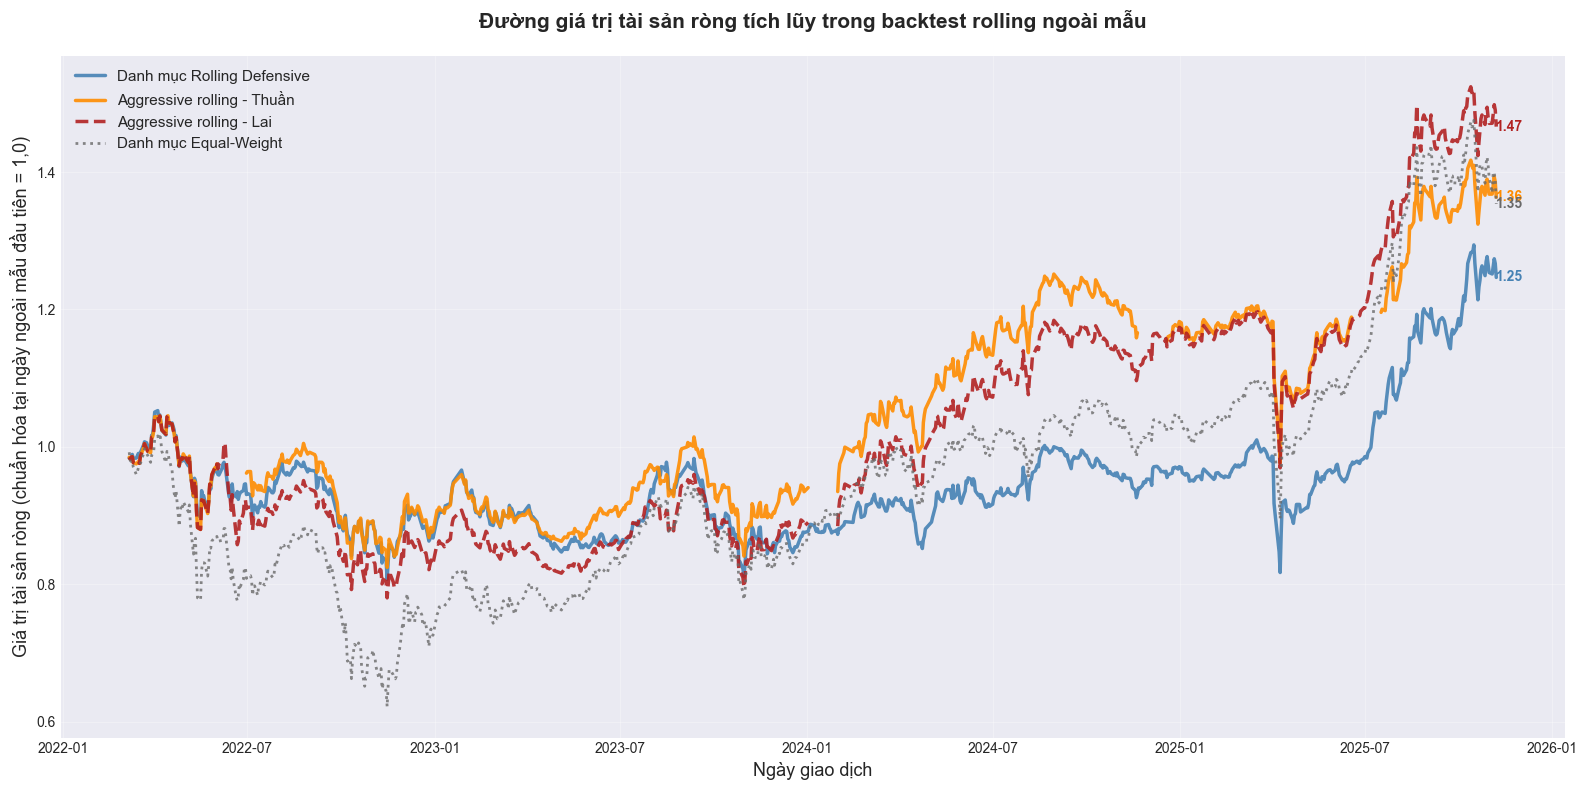

Saved figure: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\backtest_rolling\figures\rolling_equity_curves.png


In [10]:
# Equity curves
fig, ax = plt.subplots(figsize=(16, 8))

pure_nav_plot = metrics_agg_pure["NAV"].reindex(ret_def.index)
hybrid_nav_plot = metrics_agg_hybrid["NAV"].reindex(ret_def.index)
rolling_display_labels = {
    "Rolling Defensive": "Danh mục Rolling Defensive",
    "Rolling Aggressive (Pure)": "Aggressive rolling - Thuần",
    "Rolling Aggressive Hybrid": "Aggressive rolling - Lai",
    "Equal-Weight Benchmark": "Danh mục Equal-Weight",
}

ax.plot(metrics_def["NAV"].index, metrics_def["NAV"].values, label=rolling_display_labels["Rolling Defensive"], color="steelblue", linewidth=2.5, alpha=0.9)
ax.plot(pure_nav_plot.index, pure_nav_plot.values, label=rolling_display_labels["Rolling Aggressive (Pure)"], color="darkorange", linewidth=2.5, alpha=0.9)
ax.plot(hybrid_nav_plot.index, hybrid_nav_plot.values, label=rolling_display_labels["Rolling Aggressive Hybrid"], color="firebrick", linewidth=2.5, linestyle="--", alpha=0.9)
ax.plot(metrics_bench["NAV"].index, metrics_bench["NAV"].values, label=rolling_display_labels["Equal-Weight Benchmark"], color="dimgray", linewidth=2.0, linestyle=":", alpha=0.8)

ax.set_xlabel("Ngày giao dịch", fontsize=13)
ax.set_ylabel("Giá trị tài sản ròng (chuẩn hóa tại ngày ngoài mẫu đầu tiên = 1,0)", fontsize=13)
ax.set_title("Đường giá trị tài sản ròng tích lũy trong backtest rolling ngoài mẫu", fontsize=15, fontweight="bold", pad=20)
ax.legend(fontsize=11, loc="upper left", framealpha=0.95)
ax.grid(True, alpha=0.3)

for nav, color in [(metrics_def["NAV"], "steelblue"), (pure_nav_plot, "darkorange"), (hybrid_nav_plot, "firebrick"), (metrics_bench["NAV"], "dimgray")]:
    valid_nav = nav.dropna()
    final_nav = valid_nav.iloc[-1]
    ax.text(valid_nav.index[-1], final_nav, f"{final_nav:.2f}", fontsize=10, fontweight="bold", color=color, va="center", ha="left")

rolling_equity_path = FIGURES_DIR / "rolling_equity_curves.png"
fig.savefig(rolling_equity_path, dpi=200, bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"Saved figure: {rolling_equity_path}")


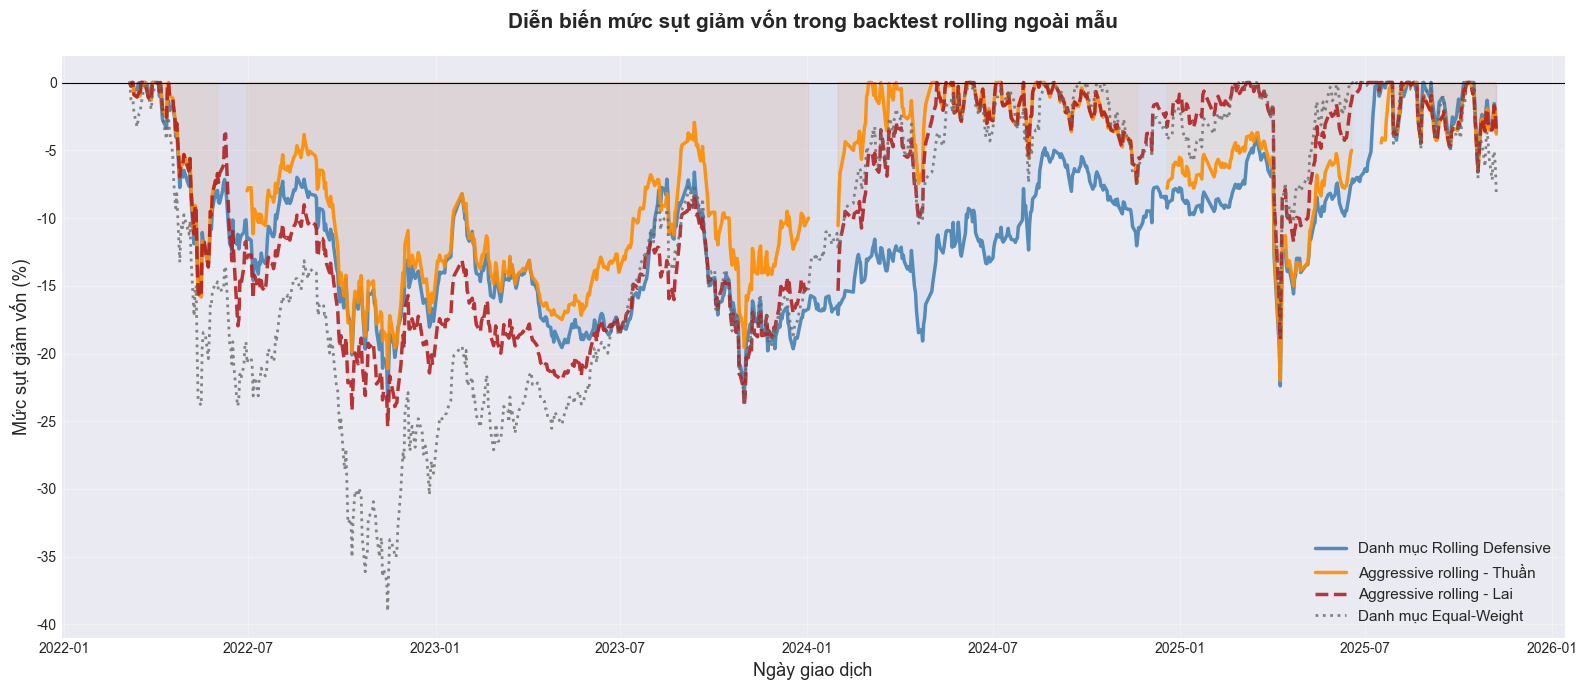

Saved figure: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\backtest_rolling\figures\rolling_drawdown_curves.png


In [11]:
# Drawdown curves
fig, ax = plt.subplots(figsize=(16, 7))

pure_drawdown_plot = metrics_agg_pure["Drawdown"].reindex(ret_def.index)
hybrid_drawdown_plot = metrics_agg_hybrid["Drawdown"].reindex(ret_def.index)

ax.plot(metrics_def["Drawdown"].index, metrics_def["Drawdown"].values * 100, label=rolling_display_labels["Rolling Defensive"], color="steelblue", linewidth=2.5, alpha=0.9)
ax.plot(pure_drawdown_plot.index, pure_drawdown_plot.values * 100, label=rolling_display_labels["Rolling Aggressive (Pure)"], color="darkorange", linewidth=2.5, alpha=0.9)
ax.plot(hybrid_drawdown_plot.index, hybrid_drawdown_plot.values * 100, label=rolling_display_labels["Rolling Aggressive Hybrid"], color="firebrick", linewidth=2.5, linestyle="--", alpha=0.9)
ax.plot(metrics_bench["Drawdown"].index, metrics_bench["Drawdown"].values * 100, label=rolling_display_labels["Equal-Weight Benchmark"], color="dimgray", linewidth=2.0, linestyle=":", alpha=0.8)

ax.fill_between(metrics_def["Drawdown"].index, metrics_def["Drawdown"].values * 100, 0, alpha=0.08, color="steelblue")
ax.fill_between(pure_drawdown_plot.index, pure_drawdown_plot.values * 100, 0, alpha=0.06, color="darkorange")
ax.fill_between(hybrid_drawdown_plot.index, hybrid_drawdown_plot.values * 100, 0, alpha=0.04, color="firebrick")

ax.set_xlabel("Ngày giao dịch", fontsize=13)
ax.set_ylabel("Mức sụt giảm vốn (%)", fontsize=13)
ax.set_title("Diễn biến mức sụt giảm vốn trong backtest rolling ngoài mẫu", fontsize=15, fontweight="bold", pad=20)
ax.legend(fontsize=11, loc="lower right", framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)

rolling_drawdown_path = FIGURES_DIR / "rolling_drawdown_curves.png"
fig.savefig(rolling_drawdown_path, dpi=200, bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"Saved figure: {rolling_drawdown_path}")


## Final Comparison and Interpretation


In [12]:
print("=" * 80)
print("ROLLING PERFORMANCE COMPARISON")
print("=" * 80)

comparison_data = {
    "Equal-Weight Benchmark": [
        metrics_bench["Annualized Mean Return (%)"],
        metrics_bench["Annualized Volatility (%)"],
        metrics_bench["Sharpe Ratio (Rf=0)"],
        metrics_bench["Max Drawdown (%)"],
    ],
    "Rolling Defensive": [
        metrics_def["Annualized Mean Return (%)"],
        metrics_def["Annualized Volatility (%)"],
        metrics_def["Sharpe Ratio (Rf=0)"],
        metrics_def["Max Drawdown (%)"],
    ],
}
hybrid_included_in_main_comparison = np.isclose(hybrid_coverage_ratio, 1.0)
if hybrid_included_in_main_comparison:
    comparison_data["Rolling Aggressive Hybrid"] = [
        metrics_agg_hybrid["Annualized Mean Return (%)"],
        metrics_agg_hybrid["Annualized Volatility (%)"],
        metrics_agg_hybrid["Sharpe Ratio (Rf=0)"],
        metrics_agg_hybrid["Max Drawdown (%)"],
    ]
else:
    print("Rolling Aggressive Hybrid is excluded from the main like-for-like comparison because coverage is incomplete.")
    print("Rolling Aggressive Hybrid remains available as a coverage-aware diagnostic series.")

comparison = pd.DataFrame(
    comparison_data,
    index=[
        "Annualized Mean Return (%)",
        "Annualized Volatility (%)",
        "Sharpe Ratio (Rf=0)",
        "Max Drawdown (%)",
    ],
)

print(comparison.round(4).to_string())

print()
print("Rebalance quality summary:")
print(f"- Defensive clean feasible solver solutions: {clean_feasible_def}/{len(rebalance_points)}")
print(f"- Defensive fallback uses: {fallback_def}/{len(rebalance_points)}")
print(f"- Defensive final feasible selections: {int(rebalance_summary['final_feasible_def'].sum())}/{len(rebalance_points)}")
print(f"- Aggressive pure-feasible rebalances: {aggressive_diagnostics['pure_feasible_rebalances']}/{aggressive_diagnostics['total_rebalances']} ({aggressive_diagnostics['pure_feasible_ratio']:.2%})")
print(f"- Aggressive fallback rebalances (Hybrid path): {aggressive_diagnostics['fallback_rebalances']}/{aggressive_diagnostics['total_rebalances']}")
print(f"- Rolling Aggressive (Pure) active OOS days: {pure_active_oos_days}/{len(ret_agg_pure)} ({pure_coverage_ratio:.2%})")
if hybrid_included_in_main_comparison:
    print("- Rolling Aggressive Hybrid is included in the main comparison because coverage is complete.")
else:
    print("- Rolling Aggressive Hybrid is not included in the main comparison/ranking block because coverage is incomplete.")
print(f"- Aggressive Hybrid final feasible selections: {int(rebalance_summary['final_feasible_agg'].sum())}/{len(rebalance_points)}")
pure_target_slack = rebalance_summary.loc[rebalance_summary['aggressive_state'] == 'pure_feasible', 'target_return_slack_agg_pure']
if pure_target_slack.empty:
    print("- Aggressive pure target-return slack: no pure-feasible rebalances")
else:
    print(f"- Aggressive pure target-return slack (min across pure-feasible rebalances): {pure_target_slack.min():.6f}")


ROLLING PERFORMANCE COMPARISON
Rolling Aggressive Hybrid is excluded from the main like-for-like comparison because coverage is incomplete.
Rolling Aggressive Hybrid remains available as a coverage-aware diagnostic series.
                            Equal-Weight Benchmark  Rolling Defensive
Annualized Mean Return (%)                 10.6536             7.5759
Annualized Volatility (%)                  21.6642            17.5283
Sharpe Ratio (Rf=0)                         0.4918             0.4322
Max Drawdown (%)                          -39.0157           -23.3335

Rebalance quality summary:
- Defensive clean feasible solver solutions: 40/46
- Defensive fallback uses: 6/46
- Defensive final feasible selections: 46/46
- Aggressive pure-feasible rebalances: 42/46 (91.30%)
- Aggressive fallback rebalances (Hybrid path): 4/46
- Rolling Aggressive (Pure) active OOS days: 840/920 (91.30%)
- Rolling Aggressive Hybrid is not included in the main comparison/ranking block because coverage is i

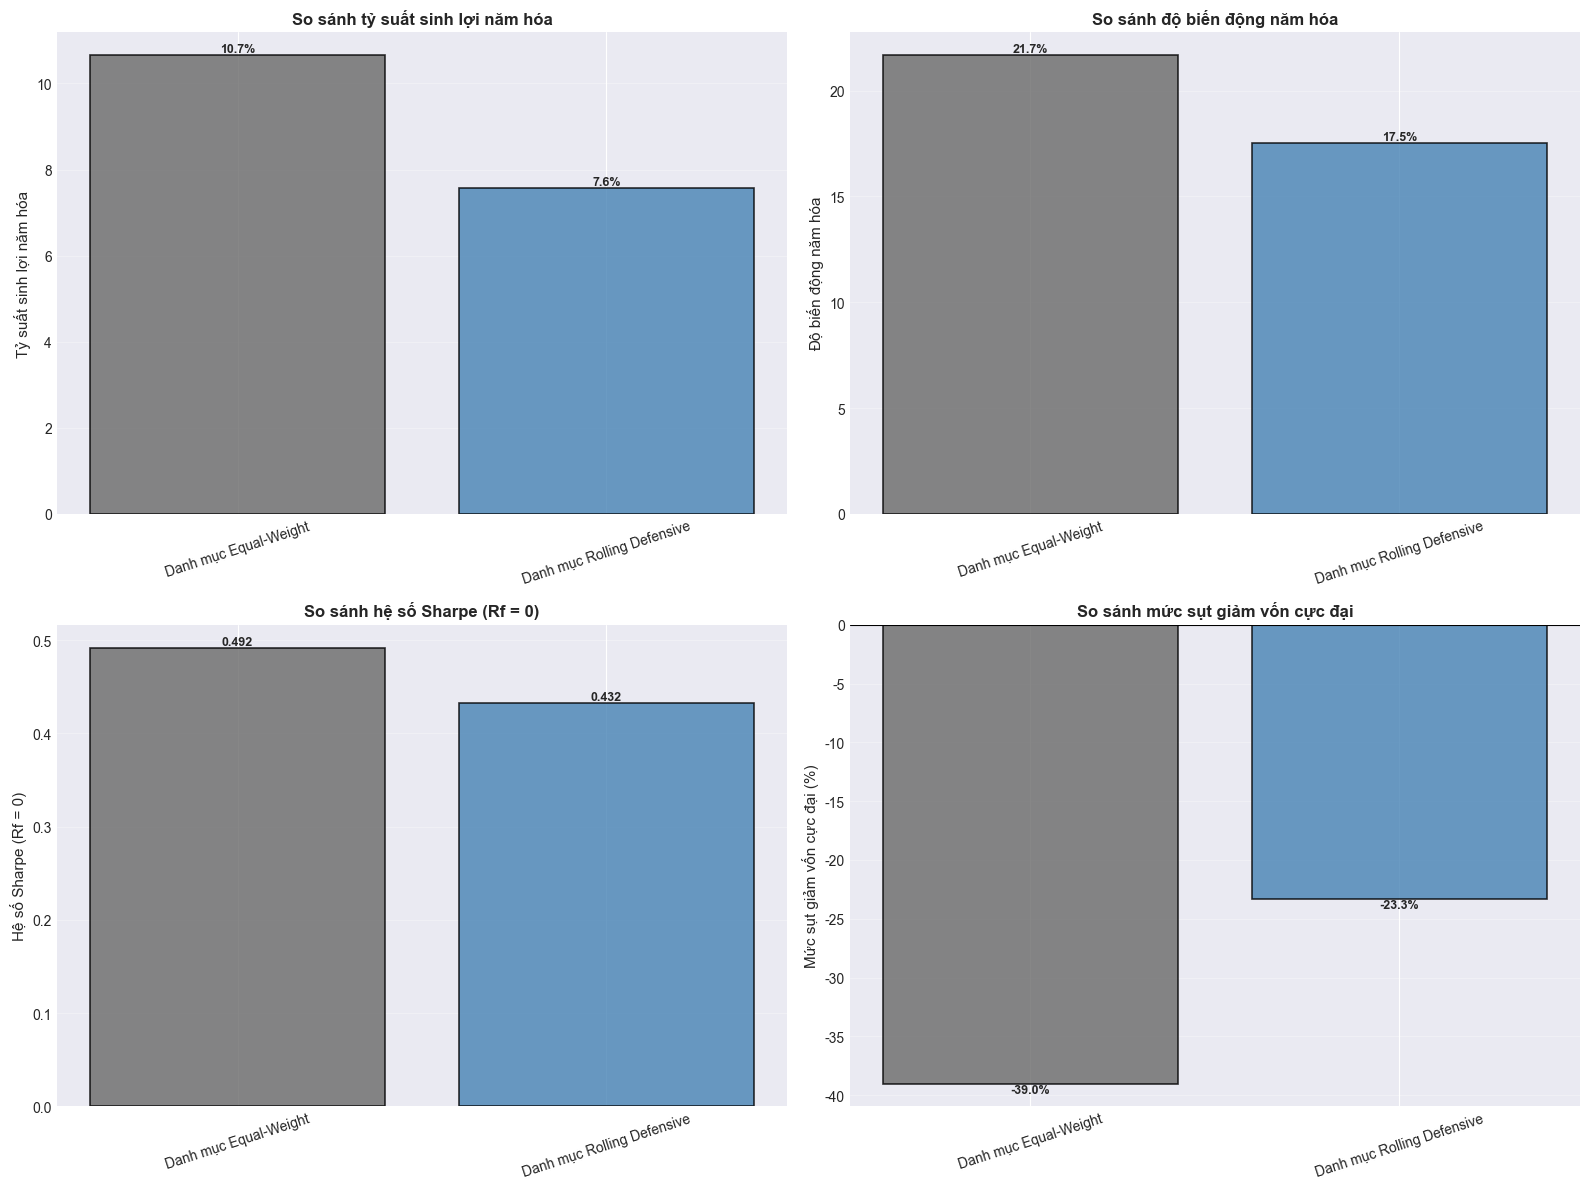

Saved figure: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\backtest_rolling\figures\rolling_metrics_comparison.png


In [13]:
# Metrics comparison chart
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

strategies = list(comparison.columns)
strategy_colors = {
    "Equal-Weight Benchmark": "dimgray",
    "Rolling Defensive": "steelblue",
    "Rolling Aggressive Hybrid": "firebrick",
}
colors = [strategy_colors[strategy] for strategy in strategies]
display_strategies = [rolling_display_labels.get(strategy, strategy) for strategy in strategies]
metric_plot_map = [
    ("Annualized Mean Return (%)", axes[0, 0], "Tỷ suất sinh lợi năm hóa", "So sánh tỷ suất sinh lợi năm hóa"),
    ("Annualized Volatility (%)", axes[0, 1], "Độ biến động năm hóa", "So sánh độ biến động năm hóa"),
    ("Sharpe Ratio (Rf=0)", axes[1, 0], "Hệ số Sharpe (Rf = 0)", "So sánh hệ số Sharpe (Rf = 0)"),
    ("Max Drawdown (%)", axes[1, 1], "Mức sụt giảm vốn cực đại (%)", "So sánh mức sụt giảm vốn cực đại"),
]

for metric_name, ax, display_ylabel, display_title in metric_plot_map:
    values = comparison.loc[metric_name, strategies].values
    bars = ax.bar(display_strategies, values, color=colors, alpha=0.8, edgecolor="black", linewidth=1.2)
    ax.set_ylabel(display_ylabel, fontsize=11)
    ax.set_title(display_title, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    if metric_name == "Max Drawdown (%)":
        ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)

    for bar in bars:
        height = bar.get_height()
        text = f"{height:.1f}%" if "%" in metric_name else f"{height:.3f}"
        ax.text(bar.get_x() + bar.get_width() / 2.0, height, text, ha="center", va="top" if height < 0 else "bottom", fontsize=9, fontweight="bold")

    ax.tick_params(axis="x", rotation=18)

rolling_metrics_path = FIGURES_DIR / "rolling_metrics_comparison.png"
fig.savefig(rolling_metrics_path, dpi=200, bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"Saved figure: {rolling_metrics_path}")


In [14]:
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print("Notebook 08 role:")
print(f"- Main rolling / walk-forward out-of-sample evaluation stage")
print(f"- Training window: {WINDOW_SIZE} days")
print(f"- Holding block: {HOLDING_PERIOD} days")
if hybrid_included_in_main_comparison:
    print(f"- Strategies compared: Equal-Weight Benchmark, Rolling Defensive, Rolling Aggressive Hybrid")
else:
    print(f"- Strategies compared: Equal-Weight Benchmark, Rolling Defensive")
    print("- Rolling Aggressive Hybrid is reported separately as a coverage-aware diagnostic because its OOS coverage is incomplete")
    print("- Rolling Aggressive Hybrid is not included in the main comparison/ranking block because coverage is incomplete")
print("- Rolling clusters are rebuilt from each training window and canonicalized to 4 labels at every rebalance")
print("- Static weights from notebook 06 are not reused here")

print()
print("Main metric snapshot:")
for strategy in comparison.columns:
    print(f"- {strategy}: return {comparison.loc['Annualized Mean Return (%)', strategy]:.2f}%, vol {comparison.loc['Annualized Volatility (%)', strategy]:.2f}%, Sharpe {comparison.loc['Sharpe Ratio (Rf=0)', strategy]:.4f}, max drawdown {comparison.loc['Max Drawdown (%)', strategy]:.2f}%")

print()
print("Feasibility and fallback reporting:")
print(f"- Defensive solver failures: {solver_fail_def}, infeasible-after-check: {infeasible_def}, fallback uses: {fallback_def}, final feasible selections: {int(rebalance_summary['final_feasible_def'].sum())}")
print(f"- Aggressive pure-feasible rebalances: {aggressive_diagnostics['pure_feasible_rebalances']}/{aggressive_diagnostics['total_rebalances']} ({aggressive_diagnostics['pure_feasible_ratio']:.2%})")
print(f"- Aggressive fallback rebalances captured by Hybrid: {aggressive_diagnostics['fallback_rebalances']}/{aggressive_diagnostics['total_rebalances']}")
print(f"- Rolling Aggressive (Pure) active OOS days: {pure_active_oos_days}/{len(ret_agg_pure)} ({pure_coverage_ratio:.2%})")
print(f"- Aggressive Hybrid final feasible selections: {int(rebalance_summary['final_feasible_agg'].sum())}/{len(rebalance_points)}")

print()
print("Methodological note:")
print("- Walk-forward timing is clean for rolling mu_t, Sigma_t, and cluster reconstruction.")
print("- No fixed full-sample cluster snapshot is reused in this notebook.")
print("- Metrics shown here are annualized mean returns, not CAGR.")
print("- Realized portfolio paths use simple returns with NAV = (1 + r_p).cumprod().")

best_sharpe_strategy = comparison.loc["Sharpe Ratio (Rf=0)"].idxmax()
print()
print("Current ranking on Sharpe (Rf=0):")
print(f"- Best Sharpe in this run: {best_sharpe_strategy} ({comparison.loc['Sharpe Ratio (Rf=0)', best_sharpe_strategy]:.4f})")
if not hybrid_included_in_main_comparison:
    print("- Rolling Aggressive Hybrid is excluded from the main ranking when coverage is incomplete.")

print()
print("Notebook outputs:")
print("- This notebook remains notebook-output-centric and does not export a new canonical CSV artifact in this pass.")
print(f"- Saved figures: {FIGURES_DIR / 'rolling_equity_curves.png'}")
print(f"- Saved figures: {FIGURES_DIR / 'rolling_drawdown_curves.png'}")
print(f"- Saved figures: {FIGURES_DIR / 'rolling_metrics_comparison.png'}")


FINAL SUMMARY
Notebook 08 role:
- Main rolling / walk-forward out-of-sample evaluation stage
- Training window: 500 days
- Holding block: 20 days
- Strategies compared: Equal-Weight Benchmark, Rolling Defensive
- Rolling Aggressive Hybrid is reported separately as a coverage-aware diagnostic because its OOS coverage is incomplete
- Rolling Aggressive Hybrid is not included in the main comparison/ranking block because coverage is incomplete
- Rolling clusters are rebuilt from each training window and canonicalized to 4 labels at every rebalance
- Static weights from notebook 06 are not reused here

Main metric snapshot:
- Equal-Weight Benchmark: return 10.65%, vol 21.66%, Sharpe 0.4918, max drawdown -39.02%
- Rolling Defensive: return 7.58%, vol 17.53%, Sharpe 0.4322, max drawdown -23.33%

Feasibility and fallback reporting:
- Defensive solver failures: 0, infeasible-after-check: 6, fallback uses: 6, final feasible selections: 46
- Aggressive pure-feasible rebalances: 42/46 (91.30%)
- A